# PyTorch 오차역전파 실습

이 노트북은 오차역전파를 작은 수식 예제부터 선형 회귀, XOR 다층 신경망까지 단계적으로 이해하도록 구성했습니다.

오차역전파는 **예측값과 정답의 차이인 손실을 계산한 뒤, 손실을 줄이기 위해 각 가중치의 수정 방향과 크기를 계산하는 과정**입니다.

In [1]:
# ============================================================
# 1. PyTorch 라이브러리 불러오기
# ============================================================

# torch는 텐서 계산, 자동 미분, 딥러닝 모델 학습을 위한 핵심 라이브러리입니다.
import torch

# torch.nn은 신경망 계층, 손실함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# matplotlib은 손실값 변화를 그래프로 확인하기 위해 사용합니다.
import matplotlib.pyplot as plt

# 실행 환경에 설치된 PyTorch 버전을 출력합니다.
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [2]:
# ============================================================
# 2. 재현성을 위한 시드 고정
# ============================================================

# 딥러닝은 가중치 초기화 등에서 무작위성이 사용됩니다.
# manual_seed를 설정하면 같은 코드를 반복 실행할 때 비슷한 결과를 얻을 수 있습니다.
torch.manual_seed(42)

## 1단계: 작은 계산식으로 역전파 이해

먼저 신경망 없이 다음 식으로 역전파를 확인합니다.

```text
예측값 = x * w
손실값 = (정답 - 예측값)^2
```

여기서 `w`는 학습으로 수정할 가중치입니다.

In [3]:
# ============================================================
# 3. 단순 계산식 예제
# ============================================================

# 입력값 x를 텐서로 생성합니다.
x = torch.tensor(2.0)

# 모델이 맞혀야 하는 정답값을 텐서로 생성합니다.
target = torch.tensor(10.0)

# 가중치 w를 텐서로 생성합니다.
# requires_grad=True는 w에 대해 기울기를 계산하겠다는 의미입니다.
w = torch.tensor(3.0, requires_grad=True)

# 순전파: 입력값 x와 가중치 w를 곱해 예측값을 계산합니다.
prediction = x * w

# 손실 계산: 정답과 예측값의 차이를 제곱합니다.
loss = (target - prediction) ** 2

# 현재 계산 결과를 출력합니다.
print("입력값 x:", x.item())
print("초기 가중치 w:", w.item())
print("예측값:", prediction.item())
print("정답값:", target.item())
print("손실값:", loss.item())

입력값 x: 2.0
초기 가중치 w: 3.0
예측값: 6.0
정답값: 10.0
손실값: 16.0


In [4]:
# ============================================================
# 4. backward()로 기울기 계산
# ============================================================

# loss.backward()는 손실값에서 시작하여 역방향으로 미분을 수행합니다.
# 이 과정이 PyTorch에서 오차역전파에 해당합니다.
loss.backward()

# w.grad에는 손실값을 w로 미분한 기울기가 저장됩니다.
# 이 값은 w를 어느 방향으로 수정해야 손실이 줄어드는지 알려줍니다.
print("w에 대한 기울기:", w.grad.item())

w에 대한 기울기: -16.0


In [5]:
# ============================================================
# 5. 기울기를 사용해 가중치 직접 수정
# ============================================================

# 학습률은 가중치를 한 번에 얼마나 수정할지 결정합니다.
learning_rate = 0.01

# 가중치 업데이트는 기울기 추적이 필요 없으므로 no_grad 안에서 수행합니다.
with torch.no_grad():
    # 경사하강법 공식: 새 가중치 = 기존 가중치 - 학습률 * 기울기
    w -= learning_rate * w.grad

# 수정된 가중치를 출력합니다.
print("수정 후 가중치 w:", w.item())

# PyTorch는 기울기를 누적하므로 다음 계산 전에 반드시 0으로 초기화해야 합니다.
w.grad.zero_()

# 초기화된 기울기를 확인합니다.
print("초기화 후 w.grad:", w.grad.item())

수정 후 가중치 w: 3.1600000858306885
초기화 후 w.grad: 0.0


## 2단계: 반복 학습으로 손실 줄이기

이제 같은 계산을 여러 번 반복하면서 손실값이 줄어드는지 확인합니다.

In [6]:
# ============================================================
# 6. 단일 가중치 반복 학습
# ============================================================

# 학습 대상 가중치를 다시 초기화합니다.
w = torch.tensor(3.0, requires_grad=True)

# 입력값과 정답값을 설정합니다.
x = torch.tensor(2.0)
target = torch.tensor(10.0)

# 학습률을 설정합니다.
learning_rate = 0.05

# 손실값을 저장할 리스트입니다.
loss_history = []

# 30번 반복 학습합니다.
for epoch in range(30):
    # 순전파: 현재 가중치로 예측값을 계산합니다.
    prediction = x * w

    # 손실 계산: 예측값과 정답값의 차이를 제곱합니다.
    loss = (target - prediction) ** 2

    # 손실값을 기록합니다.
    loss_history.append(loss.item())

    # 이전 기울기가 있으면 초기화합니다.
    if w.grad is not None:
        w.grad.zero_()

    # 역전파: 손실값을 기준으로 가중치의 기울기를 계산합니다.
    loss.backward()

    # 가중치 업데이트를 수행합니다.
    with torch.no_grad():
        w -= learning_rate * w.grad

    # 학습 과정을 출력합니다.
    print(f"epoch={epoch+1:02d}, w={w.item():.4f}, prediction={prediction.item():.4f}, loss={loss.item():.4f}")

epoch=01, w=3.8000, prediction=6.0000, loss=16.0000
epoch=02, w=4.2800, prediction=7.6000, loss=5.7600
epoch=03, w=4.5680, prediction=8.5600, loss=2.0736
epoch=04, w=4.7408, prediction=9.1360, loss=0.7465
epoch=05, w=4.8445, prediction=9.4816, loss=0.2687
epoch=06, w=4.9067, prediction=9.6890, loss=0.0967
epoch=07, w=4.9440, prediction=9.8134, loss=0.0348
epoch=08, w=4.9664, prediction=9.8880, loss=0.0125
epoch=09, w=4.9798, prediction=9.9328, loss=0.0045
epoch=10, w=4.9879, prediction=9.9597, loss=0.0016
epoch=11, w=4.9927, prediction=9.9758, loss=0.0006
epoch=12, w=4.9956, prediction=9.9855, loss=0.0002
epoch=13, w=4.9974, prediction=9.9913, loss=0.0001
epoch=14, w=4.9984, prediction=9.9948, loss=0.0000
epoch=15, w=4.9991, prediction=9.9969, loss=0.0000
epoch=16, w=4.9994, prediction=9.9981, loss=0.0000
epoch=17, w=4.9997, prediction=9.9989, loss=0.0000
epoch=18, w=4.9998, prediction=9.9993, loss=0.0000
epoch=19, w=4.9999, prediction=9.9996, loss=0.0000
epoch=20, w=4.9999, prediction

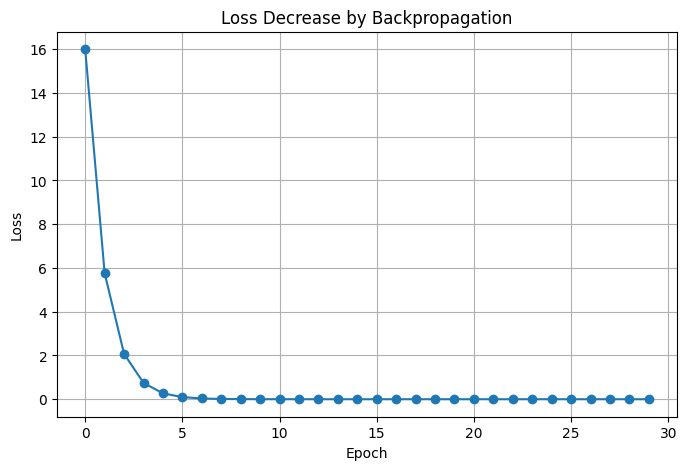

In [7]:
# ============================================================
# 7. 손실 감소 그래프 출력
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# 손실값 변화를 선 그래프로 표시합니다.
plt.plot(loss_history, marker="o")

# 그래프 제목을 설정합니다.
plt.title("Loss Decrease by Backpropagation")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 3단계: 선형 회귀 모델에서 역전파

목표는 다음 관계를 학습하는 것입니다.

```text
y = 2x + 1
```

In [8]:
# ============================================================
# 8. 학습 데이터 준비
# ============================================================

# 입력 데이터입니다. shape은 (샘플 수, 입력 특성 수)입니다.
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])

# 정답 데이터입니다. y = 2x + 1 규칙을 따릅니다.
y = torch.tensor([[3.0], [5.0], [7.0], [9.0], [11.0]])

# 데이터 형태를 확인합니다.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([5, 1])
y shape: torch.Size([5, 1])


In [9]:
# ============================================================
# 9. 선형 회귀 모델 정의
# ============================================================

# nn.Module을 상속하여 사용자 정의 모델을 만듭니다.
class LinearRegressionModel(nn.Module):
    # 모델에 필요한 계층을 정의합니다.
    def __init__(self):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # 입력 1개를 받아 출력 1개를 만드는 선형 계층입니다.
        # 내부적으로 y = xw + b 계산을 수행합니다.
        self.linear = nn.Linear(1, 1)

    # 순전파 과정을 정의합니다.
    def forward(self, x):
        # 입력 x를 선형 계층에 통과시킨 결과를 반환합니다.
        return self.linear(x)

# 모델 객체를 생성합니다.
model = LinearRegressionModel()

# 모델 구조를 출력합니다.
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [10]:
# ============================================================
# 10. 손실함수와 최적화 알고리즘 설정
# ============================================================

# MSELoss는 회귀 문제에서 예측값과 실제값의 차이를 제곱 평균으로 계산합니다.
criterion = nn.MSELoss()

# SGD는 계산된 기울기를 이용해 가중치를 조금씩 수정하는 최적화 알고리즘입니다.
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [11]:
# ============================================================
# 11. 모델 학습
# ============================================================

# 손실값을 저장할 리스트입니다.
train_losses = []

# 300번 반복 학습합니다.
for epoch in range(300):
    # 1단계 순전파: 모델이 입력 X로 예측값을 계산합니다.
    predictions = model(X)

    # 2단계 손실 계산: 예측값과 정답값의 차이를 계산합니다.
    loss = criterion(predictions, y)

    # 3단계 기울기 초기화: 이전 기울기가 누적되지 않도록 제거합니다.
    optimizer.zero_grad()

    # 4단계 역전파: 손실을 기준으로 모든 파라미터의 기울기를 계산합니다.
    loss.backward()

    # 5단계 가중치 갱신: 계산된 기울기를 사용해 파라미터를 수정합니다.
    optimizer.step()

    # 손실값을 기록합니다.
    train_losses.append(loss.item())

    # 50번마다 학습 상태를 출력합니다.
    if (epoch + 1) % 50 == 0:
        print(f"epoch={epoch+1:03d}, loss={loss.item():.6f}, weight={model.linear.weight.item():.4f}, bias={model.linear.bias.item():.4f}")

epoch=050, loss=0.003341, weight=1.9626, bias=1.1350
epoch=100, loss=0.002381, weight=1.9684, bias=1.1140
epoch=150, loss=0.001697, weight=1.9733, bias=1.0962
epoch=200, loss=0.001210, weight=1.9775, bias=1.0812
epoch=250, loss=0.000862, weight=1.9810, bias=1.0686
epoch=300, loss=0.000614, weight=1.9840, bias=1.0579


In [12]:
# ============================================================
# 12. 학습 결과 확인
# ============================================================

# 정답이 y = 2x + 1이므로 weight는 2, bias는 1에 가까워지는 것이 목표입니다.
print("학습된 weight:", model.linear.weight.item())
print("학습된 bias:", model.linear.bias.item())

# 새로운 입력값을 준비합니다.
new_x = torch.tensor([[10.0]])

# 예측에는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():
    new_prediction = model(new_x)

# 예측 결과를 출력합니다.
print("x=10일 때 예측값:", new_prediction.item())

학습된 weight: 1.983961582183838
학습된 bias: 1.05790376663208
x=10일 때 예측값: 20.897518157958984


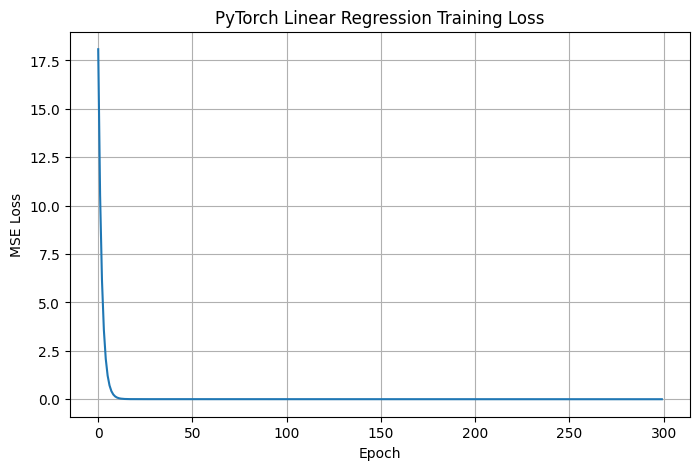

In [13]:
# ============================================================
# 13. 선형 회귀 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.title("PyTorch Linear Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## 4단계: 다층 신경망에서 역전파

XOR 문제는 단순한 직선 하나로 분리하기 어렵습니다. 은닉층이 있는 신경망을 사용하면 비선형 패턴도 학습할 수 있습니다.

In [14]:
# ============================================================
# 14. XOR 데이터 준비
# ============================================================

# XOR 입력 데이터입니다.
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])

# XOR 정답 데이터입니다. 두 입력이 다르면 1, 같으면 0입니다.
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

In [16]:
# ============================================================
# 15. XOR 다층 퍼셉트론 모델 정의
# ============================================================

class XORModel(nn.Module):
    # 모델 계층을 정의합니다.
    def __init__(self):
        # 부모 클래스 초기화입니다.
        super().__init__()

        # 입력 2개를 은닉 뉴런 8개로 변환하는 선형 계층입니다.
        self.fc1 = nn.Linear(2, 8)

        # ReLU는 비선형성을 추가하는 활성화 함수입니다.
        self.relu = nn.ReLU()

        # 은닉 뉴런 8개를 출력 1개로 변환하는 선형 계층입니다.
        self.fc2 = nn.Linear(8, 1)

        # Sigmoid는 출력값을 0~1 범위로 변환합니다.
        self.sigmoid = nn.Sigmoid()

    # 순전파를 정의합니다.
    def forward(self, x):
        # 첫 번째 선형 계층을 통과합니다.
        x = self.fc1(x)

        # ReLU 활성화 함수를 적용합니다.
        x = self.relu(x)

        # 두 번째 선형 계층을 통과합니다.
        x = self.fc2(x)

        # Sigmoid로 확률 형태의 출력을 만듭니다.
        x = self.sigmoid(x)

        # 최종 결과를 반환합니다.
        return x

# XOR 모델을 생성합니다.
xor_model = XORModel()

# 모델 구조를 출력합니다.
print(xor_model)

XORModel(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [17]:
# ============================================================
# 16. XOR 모델 학습 설정
# ============================================================

# BCELoss는 이진 분류 문제에서 사용하는 손실함수입니다.
xor_criterion = nn.BCELoss()

# Adam은 학습률을 적응적으로 조정하는 최적화 알고리즘입니다.
xor_optimizer = optim.Adam(xor_model.parameters(), lr=0.05)

# 손실값 기록 리스트입니다.
xor_losses = []

In [18]:
# ============================================================
# 17. XOR 모델 학습
# ============================================================

# 1000번 반복 학습합니다.
for epoch in range(1000):
    # 순전파로 예측값을 계산합니다.
    xor_pred = xor_model(X_xor)

    # 예측값과 정답값을 비교하여 손실을 계산합니다.
    xor_loss = xor_criterion(xor_pred, y_xor)

    # 이전 기울기를 초기화합니다.
    xor_optimizer.zero_grad()

    # 역전파로 각 가중치의 기울기를 계산합니다.
    xor_loss.backward()

    # 계산된 기울기로 가중치를 수정합니다.
    xor_optimizer.step()

    # 손실값을 기록합니다.
    xor_losses.append(xor_loss.item())

    # 200번마다 손실을 출력합니다.
    if (epoch + 1) % 200 == 0:
        print(f"epoch={epoch+1:04d}, loss={xor_loss.item():.6f}")

epoch=0200, loss=0.001184
epoch=0400, loss=0.000372
epoch=0600, loss=0.000183
epoch=0800, loss=0.000109
epoch=1000, loss=0.000073


In [19]:
# ============================================================
# 18. XOR 예측 결과 확인
# ============================================================

# 모델을 평가 모드로 변경합니다.
xor_model.eval()

# 예측에는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():
    # XOR 입력에 대한 예측 확률을 계산합니다.
    xor_outputs = xor_model(X_xor)

    # 0.5 이상이면 1, 미만이면 0으로 분류합니다.
    xor_classes = (xor_outputs >= 0.5).float()

# 결과를 출력합니다.
print("예측 확률:")
print(xor_outputs)
print("예측 클래스:")
print(xor_classes)
print("실제 정답:")
print(y_xor)

예측 확률:
tensor([[6.0647e-05],
        [9.9992e-01],
        [9.9993e-01],
        [8.2106e-05]])
예측 클래스:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
실제 정답:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


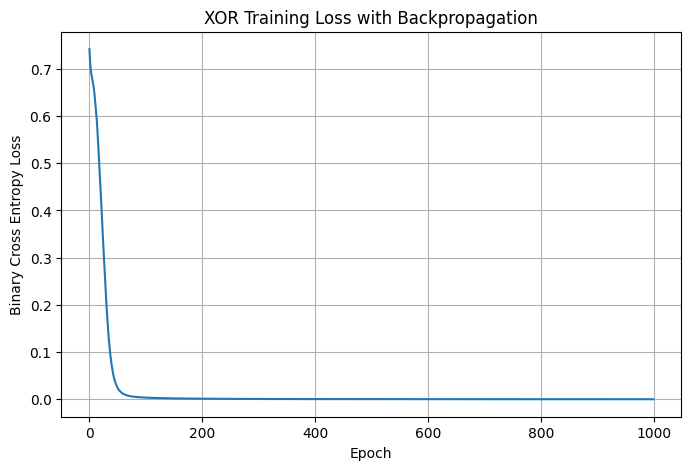

In [20]:
# ============================================================
# 19. XOR 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(xor_losses)
plt.title("XOR Training Loss with Backpropagation")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

# PyTorch 핵심 정리

PyTorch에서 오차역전파의 핵심 코드는 다음 3줄입니다.

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

- `optimizer.zero_grad()` : 이전 기울기를 초기화합니다.
- `loss.backward()` : 손실을 기준으로 역전파를 수행합니다.
- `optimizer.step()` : 계산된 기울기로 가중치와 편향을 수정합니다.